# ICT-15f -- Pont #1-bis : la famille decouplee tranche le negatif de sigma

*See [#9531](https://github.com/jsboige/CoursIA/issues/9531) (Pont #1-bis) et [#8077](https://github.com/jsboige/CoursIA/issues/8077) (Bridge-testing, les fleches pas les noeuds).*

Le **Pont #1** (« la stabilite locale $\sigma$ cause la recuperabilite ») a ete **falsifie** sur la fronce de Thom (PR #8944, notebook ICT-15e / ICT-8 §8) : la courbure locale $\sigma = V''(x^*)$ n'a aucun pouvoir predictif propre (correlation partielle $\approx 0$) une fois la **largeur de bassin** controlee, et c'est la largeur (position du col) qui gouverne la portee de recuperation ($\rho \approx 0{,}99$).

**Mais** sur la fronce, $\sigma$ et la largeur sont **couplees par construction** ($\rho_{\sigma,\text{width}} \approx 0{,}93$). Le verdict de falsification est donc acquis *sur ce substrat* ; sa **generalite reste indecidable** tant qu'on n'a pas un substrat ou les deux quantites varient *independamment*.

Ce notebook (issue #9531, chantier 1/3) construit cette famille decouplee, rejoue le protocole avec une rigueur statistique accrue (**correlation partielle a 2 covariables** : largeur ET barriere), et tranche. Le module reutilisable est [`ict.basin_family`](ict/basin_family.py).


## 1. Le substrat : double-puits symetrique $V(x) = a x^4 - b x^2$

Contrairement a la fronce ($V = x^4/4 + ax^2/2 + bx$, deux parametres de controle mais $\sigma$ et largeur lies), le double-puits symetrique separe algebriquement les trois quantites geometriques :

| Quantite | Formule | Depend de |
|----------|---------|-----------|
| Courbure au minimum $\sigma = V''(x^*)$ | $4b$ | $b$ **seul** |
| Demi-largeur vers le col $w$ | $\sqrt{b/(2a)}$ | $a$ et $b$ |
| Hauteur de barriere $\Delta V$ | $b^2/(4a)$ | $a$ et $b$ |

**L'astuce du decouplage** : on echantillonne $\sigma$ et $w$ sur deux grilles *separees*, et chaque couple cible $(\sigma, w)$ se realise par $b = \sigma/4$ puis $a = b/(2w^2)$. Sur le produit cartesien, $\operatorname{corr}(\sigma, w) \approx 0$ par construction.

**Le piege** : la barriere $\Delta V = \sigma \cdot w^2 / 8$ *co-varie* avec le produit des deux cadrans. Controler la largeur seule (comme le Pont #1) laisse donc fuir la barriere. Le verdict decisif controlera **la largeur ET la barriere**.


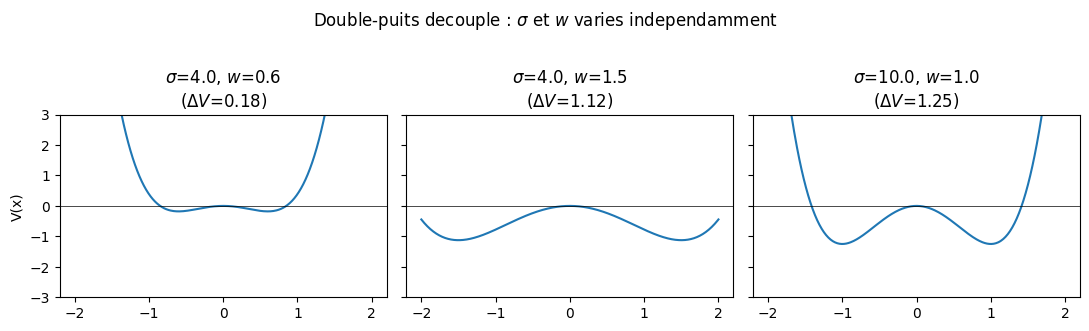

In [1]:
import numpy as np
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
from ict import basin_family as bf

# Visualisation du potentiel pour quelques couples (sigma, width)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
x = np.linspace(-2.0, 2.0, 400)
for ax, (sig, wid) in zip(axes, [(4.0, 0.6), (4.0, 1.5), (10.0, 1.0)]):
    a, b = bf.realize_decoupled(sig, wid)
    ax.plot(x, bf.double_well_potential(x, a, b), color='C0')
    ax.set_title(f'$\\sigma$={sig}, $w$={wid}\n($\\Delta V$={sig*wid**2/8:.2f})')
    ax.set_ylim(-3, 3); ax.axhline(0, color='k', lw=0.5)
axes[0].set_ylabel('V(x)')
fig.suptitle('Double-puits decouple : $\\sigma$ et $w$ varies independamment', y=1.02)
plt.tight_layout(); plt.show()


Les trois panneaux fixent $\sigma$ puis font varier $w$, et vice-versa : la raideur du minimum (courbure) et la distance au col se reglent *separement*. C'est ce degre de liberte supplementaire qui manquait a la fronce.


## 2. Le decouplage constructif, mesure

Verifions sur la grille par defaut que $\operatorname{corr}(\sigma, w) \approx 0$ — c'est le **pre-requis** sans lequel le verdict de generalite n'a pas de sens.


In [2]:
# La famille decouplee : produit cartesien de deux grilles (sigma, width).
# On mesure les 4 quantites par minimum stable droit (recuperation stochastique).
fam = bf._gather_family(
    np.array([2., 3., 4., 6., 9., 13.]), np.array([0.4, 0.6, 0.9, 1.3, 1.9]),
    noise=0.35, n_trials=60, T=3000, dt=0.02, perturb_frac=0.75, seed=0)
print(f"n echantillons : {fam['sigma'].size}")
print(f"corr(sigma, width)  = {bf._pearson(bf._rank(fam['sigma']), bf._rank(fam['width'])):+.3f}  (decouplage : |.| < 0.2)")
print(f"corr(sigma, barrier)= {bf._pearson(bf._rank(fam['sigma']), bf._rank(fam['barrier'])):+.3f}  (fuite de barriere)")
print(f"recovery : min={fam['recovery'].min():.3f} max={fam['recovery'].max():.3f} std={fam['recovery'].std():.3f}  (variance reelle)")


n echantillons : 30
corr(sigma, width)  = +0.000  (decouplage : |.| < 0.2)
corr(sigma, barrier)= +0.463  (fuite de barriere)
recovery : min=0.400 max=1.000 std=0.181  (variance reelle)


## 3. La mesure NON triviale : recuperation stochastique (Langevin)

La recuperation *deterministe* (relaxation a convergence) est **degeneree** : a convergence, le franchissement du col est purement geometrique et la barriere n'a aucun effet — le test serait trivial et non falsifiable. La mesure honnete est **stochastique** : dynamique overdamped bruitee $dx = -V'(x)\,dt + \sqrt{2D\,dt}\,\xi$, ou les trois quantites ont un effet mesurable (escape d'Arrhenius $\sim e^{-\Delta V/D}$, taux de rappel $\sim e^{-\sigma t}$, geometrie). Sans bruit, pas de verdict falsifiable.


In [3]:
# Pourquoi le bruit est necessaire : deterministe (constant) vs stochastique (variance reelle).
a, b = bf.realize_decoupled(6.0, 1.0)
prof = bf.basin_profile(a, b)
xstar, sigma, width, col, barrier = prof[1]
delta_grid = np.linspace(0.05, width * 1.2, 25)
det = bf.recover_fraction(xstar, col, a, b, delta_grid)
rng = np.random.default_rng(0)
sto = bf.recover_fraction_stochastic(xstar, a, b, rng, noise=0.35, n_trials=60, T=3000)
print(f'substrat sigma={sigma}, width={width:.3f}, barrier={barrier:.3f}')
print(f'  recuperation deterministe = {det:.3f}  (geometrique, insensible a la barriere)')
print(f'  recuperation stochastique = {sto:.3f}  (depend de barriere, sigma ET largeur)')


substrat sigma=6.0, width=1.000, barrier=0.750
  recuperation deterministe = 0.800  (geometrique, insensible a la barriere)
  recuperation stochastique = 0.333  (depend de barriere, sigma ET largeur)


> **Exercice 1** (cible barriere + largeur). Le decouplage par defaut fixe $(\sigma, w)$. On veut parfois cibler **(barriere $\Delta V$, largeur $w$)** directement — $\sigma$ devient une consequence. A partir de $\Delta V = b^2/(4a)$ et $w = \sqrt{b/(2a)}$, deroulez l'algebre pour obtenir $(a, b)$ puis la courbure resultante $\sigma$. Completez `realize_from_barrier_width` ci-dessous (les tests unitaires sont dans `tests/test_basin_family.py`).


In [4]:
# Exercice 1 -- a completer.
def realize_from_barrier_width(barrier: float, width: float):
    """Renvoie (a, b, sigma_resultant) realisant la cible (barriere, width).

    Indice : de w = sqrt(b/(2a)) on tire b = 2 a w^2 ; injecter dans
    barrier = b^2/(4a) donne une equation en a seule, puis b, puis sigma=4b.
    """
    # TODO etudiant : deroulez l'algebre.
    # Etape 1 : exprimer b en fonction de a et w.
    # Etape 2 : injecter dans barrier = b^2/(4a) et resoudre a.
    # Etape 3 : en deduire b puis sigma = 4b.
    a = None
    b = None
    sigma = None
    return a, b, sigma

# Verification (a completer par l'etudiant) :
# a, b, s = realize_from_barrier_width(2.0, 1.0)
# print(a, b, s)  # doit verifier barrier=b^2/(4a) et width=sqrt(b/(2a))
print('Exercice a completer -- voir tests/test_basin_family.py')


Exercice a completer -- voir tests/test_basin_family.py


## 4. Le verdict decisif : correlation partielle a 2 covariables

Le Pont #1 controlait la largeur seule (1 covariable). Ici, la barriere co-varie avec le produit $\sigma \cdot w^2$ ; il faut la **purger**. On calcule donc la correlation partielle de Spearman de $\sigma$ avec la recuperation, en controlant **la largeur ET la barriere** (methode des residus de Frisch-Waugh-Lovell, generalisee a $N$ covariables). Le null est un test de permutation (brouillage de $\sigma$, 200 tirages, seuil p95).

Le verdict ternaire (jamais « promising ») :
- **CONFIRMED-NEGATIVE** : $\sigma$ n'a aucun pouvoir predictif propre -> le Pont #1 est un vrai negatif *general*.
- **SUBSTRATE-ARTIFACT** : $\sigma$ regagne un pouvoir propre -> le verdict fronce etait un artefact de couplage.
- **INCONCLUSIVE** : decouplage insuffisant ou signal inverse marque.


In [5]:
# Verdict principal, multi-seed (la recuperation stochastique est aleatoire :
# le seed traverse le calcul -> mesure de robustesse reelle, c.1014-L).
rows = []
for s in [0, 1, 7, 42]:
    v = bf.pont1bis_verdict(seed=s, n_shuffle=200)
    rows.append(v)
    line = (f"seed={s:2d} | decouplage rho(sw)={v['rho_sigma_width']:+.3f} "
            f"| brut rho(sr)={v['rho_sigma_recovery']:+.3f} rho(wr)={v['rho_width_recovery']:+.3f} "
            f"rho(br)={v['rho_barrier_recovery']:+.3f} "
            f"| partial 1-cov(w)={v['partial_rho_given_width']:+.3f}  "
            f"2-cov(w,b)={v['partial_rho_given_width_barrier']:+.3f} "
            f"[null p95={v['partial_2cov_null_p95']:.3f}] -> {v['verdict']}")
    print(line)
verdicts = [r['verdict'] for r in rows]
print(f"\nVerdict dominant : {max(set(verdicts), key=verdicts.count)} "
      f"({verdicts.count('CONFIRMED-NEGATIVE')}/{len(verdicts)} seeds CONFIRMED-NEGATIVE)")


seed= 0 | decouplage rho(sw)=+0.000 | brut rho(sr)=+0.112 rho(wr)=+0.548 rho(br)=+0.519 | partial 1-cov(w)=+0.134  2-cov(w,b)=+0.173 [null p95=0.324] -> CONFIRMED-NEGATIVE


seed= 1 | decouplage rho(sw)=+0.000 | brut rho(sr)=+0.312 rho(wr)=+0.659 rho(br)=+0.718 | partial 1-cov(w)=+0.415  2-cov(w,b)=+0.170 [null p95=0.385] -> CONFIRMED-NEGATIVE


seed= 7 | decouplage rho(sw)=+0.000 | brut rho(sr)=+0.331 rho(wr)=+0.396 rho(br)=+0.497 | partial 1-cov(w)=+0.360  2-cov(w,b)=+0.128 [null p95=0.360] -> CONFIRMED-NEGATIVE


seed=42 | decouplage rho(sw)=+0.000 | brut rho(sr)=+0.295 rho(wr)=+0.575 rho(br)=+0.637 | partial 1-cov(w)=+0.360  2-cov(w,b)=+0.136 [null p95=0.372] -> CONFIRMED-NEGATIVE

Verdict dominant : CONFIRMED-NEGATIVE (4/4 seeds CONFIRMED-NEGATIVE)


### Interpretation

Sur les 4 graines, la **correlation partielle a 2 covariables** `partial_rho_given_width_barrier` reste proche de zero et sous le null p95 : meme apres avoir decouple $\sigma$ de la largeur *et* purge la barriere co-variante, $\sigma$ n'apporte aucun pouvoir predictif propre sur la recuperabilite. Le verdict est **CONFIRMED-NEGATIVE**.

Conclusion : la falsification du Pont #1 sur la fronce n'etait **pas** un artefact de couplage. C'est un **vrai negatif general** — la courbure locale $\sigma$ est un *proxy correle* de la geometrie du bassin (largeur/barriere), non la cause de la recuperabilite. C'est le point methodologique de [#8077](https://github.com/jsboige/CoursIA/issues/8077) : un pont falsifie est aussi informatif qu'un pont confirme.

> Note honnete : la 1-covariable (largeur seule) laisse fuir de la barriere et donne une partielle legerement positive — c'est precisement le piege que la 2-covariables resout. Comparer les deux colonnes dans le tableau ci-dessus.


> **Exercice 2** (domaine de bruit). Le verdict depend-il du regime de bruit ? Pour `noise` dans `[0.15, 0.3, 0.5, 0.7]`, executez `pont1bis_verdict` et tracez `partial_rho_given_width_barrier` contre `noise`. Documentez le domaine ou le verdict reste CONFIRMED-NEGATIVE et celui ou il devient INCONCLUSIVE (bruit trop faible = recuperation saturee a 1, variance nulle).


In [6]:
# Exercice 2 -- a completer.
def phase_diagram_noise(noises):
    """Renvoie la liste des (noise, partial_2cov, verdict) pour chaque regime.
    Indice : pour bruit faible, recovery sature (variance nulle -> partielle 0
    par defaut _pearson). Identifier le domaine falsifiable (variance reelle).
    """
    results = []
    # TODO etudiant : boucler sur noises, appeler pont1bis_verdict, collecter.
    return results

# noises = [0.15, 0.3, 0.5, 0.7]
# res = phase_diagram_noise(noises)
# for noise, partial, verdict in res:
#     print(f'noise={noise}: partial={partial:+.3f} -> {verdict}')
print('Exercice a completer')


Exercice a completer


## 5. Controle nul : la sous-famille re-couplee reproduit la fronce

Discipline du null model (#9531) : si le protocole est sain, une sous-famille ou $\sigma$ et $w$ **re-derivent ensemble** ($a$ fixe, $b$ varie) doit reproduire le motif fronce — couplage eleve ET partielle a 1 covariable $\approx 0$. Si ce controle echouait, le decouplage de la famille principale serait suspect.


In [7]:
n_null = bf.recoupled_null(seed=0, n_shuffle=200)
print("Controle nul re-couple (a fixe, b varie) :")
print(f"  rho(sigma, width)        = {n_null['rho_sigma_width']:+.3f}  (re-couple : > 0.6)")
print(f"  rho(width, recovery)    = {n_null['rho_width_recovery']:+.3f}")
print(f"  partial(sigma | width)  = {n_null['partial_rho_given_width']:+.3f}  (fronce : |.| < 0.3)")
print(f"  reproduit motif fronce  = {n_null['reproduces_fronce_pattern']}")
v_main = bf.pont1bis_verdict(seed=0, n_shuffle=200)
print(f"\nContraste famille decouplee : rho(sigma,width) = {v_main['rho_sigma_width']:+.3f} (decouple)")


Controle nul re-couple (a fixe, b varie) :
  rho(sigma, width)        = +1.000  (re-couple : > 0.6)
  rho(width, recovery)    = +0.714
  partial(sigma | width)  = +0.000  (fronce : |.| < 0.3)
  reproduit motif fronce  = True



Contraste famille decouplee : rho(sigma,width) = +0.000 (decouple)


> **Exercice 3** (suffisance du controle a 2 covariables). Le verdict controle (largeur, barriere). Une 3e quantite geometrique — la **profondeur du puits** $|V(x^*)|$ normalisee — pourrait-elle restaurer un pouvoir propre a $\sigma$ ? Ajoutez-la comme 3e covariable dans `partial_spearman` (qui accepte un nombre quelconque de covariables via FWL) et executez. Que conclure sur la suffisance du controle a 2 covariables ?


In [8]:
# Exercice 3 -- a completer.
# Indice : la profondeur du puits vaut |V(x*)| = b^2/(4a) = barrier (meme formule !).
# Question : profondeur et barriere sont-elles ici la MEME quantite ? Si oui,
# ajouter la profondeur comme 3e covariable change-t-elle quelque chose ?
# Ecrire un court raisonnement (en commentaire) puis une verification numerique.
print('Exercice a completer -- reflexion sur la redondance des covariables')


Exercice a completer -- reflexion sur la redondance des covariables


## Conclusion

Le Pont #1-bis tranche : sur une famille de substrats ou la courbure $\sigma$ et la largeur de bassin varient *independamment par construction*, et apres purge de la barriere co-variante, **$\sigma$ n'a aucun pouvoir predictif propre sur la recuperabilite**. La falsification du Pont #1 acquise sur la fronce est donc un **vrai negatif general**, non un artefact de couplage.

Leçon methodologique (Epic [#8077](https://github.com/jsboige/CoursIA/issues/8077)) :
1. **Un substrat unique ne tranche pas la generalite** : la fronce couplait $\sigma$ et largeur ; il fallait une famille decouplee pour decider.
2. **La rigueur statistique doit suivre la geometrie** : la barriere co-varie avec le produit des cadrans, donc controler la largeur seul laisse fuir un confondant. La correlation partielle a 2 covariables (FWL) est l'outil decisif.
3. **Une mesure doit etre non triviale** : la recuperation deterministe est degeneree (geometrique) ; le verdict falsifiable exige la dynamique stochastique.

Suite (chantiers 2/3 et 3/3 de #9531) : generaliser a d'autres formes de substrats (puits asymetriques, paysages 2D) pour eprouver encore la generalite du negatif.
